
# Modelo CAR (Conditional Autoregressive) — Heterogeneidad espacial de los Altiplanos (v2)

## Introducción

**Qué se busca:** en `05_modelo_jerarquico_cordilleras_v2.ipynb` la zona entró como un
efecto categórico grueso (cada región tiene su propio nivel base), y en
`10_SAR_altiplanos_v2.ipynb` la dependencia espacial se modeló sobre la altitud continua de
los 491 altiplanos. Aquí se da el paso que faltaba del libro guía (`11_CAR`): un modelo
**CAR (autorregresivo condicional)** que incorpora la **heterogeneidad espacial** mediante
un **efecto aleatorio espacialmente estructurado** — cada unidad areal tiene un efecto que
está condicionalmente correlacionado con el de sus vecinas.

**Por qué CAR sí aplica aquí (y no sobre los 491 polígonos):** el CAR necesita unidades
areales con **contigüidad real** (vecindad de borde). Los 491 altiplanos NO son contiguos
entre sí (por eso en `02_v2`/`10_SAR` se usó KNN sobre centroides como sustituto). En
cambio, si se **agrega el territorio a una grilla regular**, las celdas SÍ tienen
contigüidad Rook verdadera — y ese es el insumo natural del CAR.

**Cómo entran los clusters (pedido del usuario):** la zonificación de
`Clustering_Regiones_v2.ipynb` (4 regiones) entra como **covariable categórica de efecto
fijo** — captura las diferencias de gran escala entre regiones —, mientras que el efecto
aleatorio CAR captura la heterogeneidad espacial fina que las covariables y las regiones no
explican. Es decir, el modelo combina **dos mecanismos de heterogeneidad espacial a la vez**:
zonas (grande) + suavizado espacial condicional (fino).

**Método del libro utilizado:** `11_CAR`. Se ajusta con **`CARBayes` (R, estimación
bayesiana por MCMC)** — la única vía viable en este entorno, ya que `INLA` no corre en
Windows nativo (ver `CONTEXTO_PROYECTO_v2.md`, sección 5). El modelo principal es el **CAR de
Leroux** (`S.CARleroux`), que estima un parámetro **ρ** de fuerza de dependencia espacial
(ρ=0 → independiente; ρ→1 → CAR intrínseco).

## Decisiones de diseño (documentadas para trazabilidad)

- **Unidad areal = celda de 5 km** (agregación 100× desde los 50 m nativos). No es 1 km
  como en `Clustering_Regiones_v2` por una **restricción computacional dura**: `CARBayes`
  usa una matriz de vecindad **densa** K×K, y su MCMC escala ≈ O(N²·⁵). A 1 km serían
  ~62.000 celdas (matriz densa ≈ 30 GB, inviable); a 5 km son ~2.600 celdas (~5 min de
  MCMC). 5 km es además la escala natural de un CAR regional.
- **Respuesta binaria por celda** (Bernoulli), no binomial de conteo. Se intentó primero el
  binomial (nº de píxeles altiplano / nº de píxeles válidos, denominador hasta 10.000):
  **diverge** (τ²≈10⁶, DIC=∞) porque con denominadores tan grandes cada celda se estima con
  precisión casi perfecta y el efecto CAR interpola los logits ±∞ de las celdas 0 %/100 %
  en vez de suavizar. La forma robusta y estándar en el libro para un fenómeno raro y
  agrupado es el **CAR areal binario**: la celda es *Altiplano* si **≥ 25 %** de sus píxeles
  lo son. Se documenta el intento binomial como hallazgo (igual que se hizo con cloglog y
  MGWR-multiescala en otros notebooks).
- **Prior débilmente informativo sobre τ²** (varianza del efecto espacial): incluso en la
  forma binaria, el prior vago por defecto de `CARBayes` (IG(1, 0.01)) hace que el efecto
  aleatorio por celda produzca **separación perfecta** (τ²→10⁵, DIC=∞, probabilidades NaN en
  las celdas positivas). Se usa **IG(2, 1)** (media a priori τ²=1), la práctica estándar
  para regularizar efectos aleatorios en outcomes areales binarios.
- **Cómo evaluar un CAR (clave):** el efecto aleatorio tiene ~un parámetro por celda, así
  que **reproduce el mapa observado casi perfectamente** (AUC in-sample ≈ 1). Eso NO es
  capacidad predictiva; es lo esperado en un suavizador espacial. La comparación válida entre
  modelos es por **DIC / WAIC**, que penalizan el número efectivo de parámetros (p.d) — la
  métrica del capítulo `11_CAR`.


## [0] Configuración: rutas, semilla, rutas de R y carpetas

In [1]:
import os
import subprocess   # invoca R (Rscript.exe) desde Python: CARBayes sólo existe en R
import time
import warnings

import numpy as np
import pandas as pd
import rasterio
from rasterio.warp import reproject, Resampling
import geopandas as gpd
from shapely.geometry import box   # construir el polígono cuadrado de cada celda de 5 km

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix, classification_report, roc_curve, roc_auc_score

warnings.filterwarnings("ignore")

RAIZ = r"C:\Users\MSI\Desktop\Universidad\Analisis_Geoespacial"
CARPETA_RASTER = os.path.join(RAIZ, r"Raster\50m_UTM\Analisis")
CARPETA_RESULTADOS = os.path.join(RAIZ, "Resultados")
CARPETA_FIGURAS = os.path.join(CARPETA_RESULTADOS, "11_CAR_altiplanos_v2")
os.makedirs(CARPETA_FIGURAS, exist_ok=True)

# Carpeta de intercambio Python <-> R (Python escribe celdas.csv/edges.csv; R devuelve los resultados)
CARPETA_IO = os.path.join(CARPETA_RESULTADOS, "11_CAR_io")
os.makedirs(CARPETA_IO, exist_ok=True)

# Ejecutable de R (documentado en CONTEXTO_PROYECTO_v2.md, seccion 5)
RSCRIPT = r"C:\Program Files\R\R-4.6.1\bin\Rscript.exe"

SEMILLA = 42
FACTOR_AGREGACION = 100      # 100 x 50 m = 5 km -> reduce ~62k celdas a ~2.6k (CAR es O(N^2.5))
UMBRAL_VALIDEZ = 0.10        # celda valida si >= 10% de sus pixeles son validos
UMBRAL_CELDA_ALTIPLANO = 0.25  # celda = Altiplano si >= 25% de sus pixeles lo son
np.random.seed(SEMILLA)

print(f"Carpeta de figuras: {CARPETA_FIGURAS}")
print(f"R: {RSCRIPT}  (existe: {os.path.exists(RSCRIPT)})")

Carpeta de figuras: C:\Users\MSI\Desktop\Universidad\Analisis_Geoespacial\Resultados\11_CAR_altiplanos_v2
R: C:\Program Files\R\R-4.6.1\bin\Rscript.exe  (existe: True)



## [1] Cargar rásters (50 m) y alinear la capa de Altiplanos

Mismas capas que `Clustering_Regiones_v2.ipynb` (`DEM_NA_50`, `Pendiente`,
`Relieve_Relativo`) más `Altiplanos.tif` (respuesta) y la zonificación de regiones ya
exportada (`zonas_clustering_regiones_v2.tif`, valores −1 = NoData, 0–3 = región).


In [2]:
# Carga las 4 capas raster nativas (50 m) + el raster de zonas del clustering de regiones.
t_inicio = time.time()
with rasterio.open(f"{CARPETA_RASTER}\\DEM_NA_50.tif") as s:
    dem = s.read(1).astype(np.float32); nd_dem = s.nodata
    ref_shape = s.shape; ref_transform = s.transform; ref_crs = s.crs   # grilla de referencia
with rasterio.open(f"{CARPETA_RASTER}\\Pendiente.tif") as s:
    pen = s.read(1).astype(np.float32); nd_pen = s.nodata
with rasterio.open(f"{CARPETA_RASTER}\\Relieve_Relativo.tif") as s:
    rel = s.read(1).astype(np.float32); nd_rel = s.nodata
with rasterio.open(f"{CARPETA_RASTER}\\Altiplanos.tif") as s:
    alt = np.zeros(ref_shape, dtype=np.float32)
    reproject(source=rasterio.band(s, 1), destination=alt, src_transform=s.transform,   # alinea la etiqueta a la grilla
              src_crs=s.crs, dst_transform=ref_transform, dst_crs=ref_crs,
              resampling=Resampling.nearest)
with rasterio.open(f"{CARPETA_RESULTADOS}\\zonas_clustering_regiones_v2.tif") as s:
    reg = s.read(1).astype(np.int32)   # zona (0-3) del clustering de toda la zona = heterogeneidad espacial

valido = (dem != nd_dem) & (pen != nd_pen) & (rel != nd_rel)   # píxel válido en las 3 covariables
alt_bin = (alt == 1) & valido                                  # etiqueta binaria a nivel píxel
print(f"Grilla nativa: {ref_shape} = {valido.size:,} pixeles; validos: {valido.sum():,} "
      f"({100*valido.mean():.1f}%)  CRS: {ref_crs}")
print(f"Regiones presentes: {sorted(np.unique(reg))}")

Grilla nativa: (8276, 6084) = 50,351,184 pixeles; validos: 24,783,966 (49.2%)  CRS: EPSG:32618
Regiones presentes: [np.int32(-1), np.int32(0), np.int32(1), np.int32(2), np.int32(3)]



## [2] Agregar a la grilla de 5 km

Cada celda de 5 km resume su bloque de 100×100 píxeles nativos: promedio de
Altitud/Pendiente/Relieve, número de píxeles válidos (para el umbral de validez), número
de píxeles Altiplano (para el umbral de clase), y la **región dominante** (moda del bloque,
que hereda la zonificación de `Clustering_Regiones_v2`).


In [3]:
# Agrega la grilla nativa a celdas de 5 km (bloques de 100x100 píxeles) para poder correr el CAR.
F = FACTOR_AGREGACION
fr = (ref_shape[0] // F) * F   # recorta a un múltiplo exacto de F (filas)
cr = (ref_shape[1] // F) * F   # y columnas

def bloques(m):
    # Reordena la matriz en bloques FxF: forma (n_celdas_fila, F, n_celdas_col, F).
    return m[:fr, :cr].reshape(fr // F, F, cr // F, F)

vb = bloques(valido)
n_val = vb.sum(axis=(1, 3)).astype(int)                 # nº de píxeles válidos por celda
n_alt = bloques(alt_bin).sum(axis=(1, 3)).astype(int)   # nº de píxeles Altiplano por celda

def promedio(m):
    # Promedio de la variable por celda, contando SÓLO los píxeles válidos.
    b = bloques(m); ssum = np.where(vb, b, 0).sum(axis=(1, 3))
    return np.where(n_val > 0, ssum / np.maximum(n_val, 1), np.nan)

altitud_c = promedio(dem); pendiente_c = promedio(pen); relieve_c = promedio(rel)   # covariables por celda
# Región de la celda = la zona MÁS frecuente entre sus píxeles (voto por mayoría, argmax).
conteos_region = np.stack([bloques((reg == k)).sum(axis=(1, 3)) for k in range(4)], axis=-1)
region_c = np.where(conteos_region.sum(-1) > 0, conteos_region.argmax(-1), -1)

nrow, ncol = n_val.shape
mask_celda = n_val >= (F * F * UMBRAL_VALIDEZ)                  # celda válida (>= 10% de píxeles con dato)
prop_alt = np.where(n_val > 0, n_alt / np.maximum(n_val, 1), 0.0)   # proporción de Altiplano en la celda
y_bin = (prop_alt >= UMBRAL_CELDA_ALTIPLANO).astype(int)       # etiqueta areal binaria (umbral 25%)

print(f"Grilla 5 km: {n_val.shape} = {n_val.size} celdas totales")
print(f"Celdas validas (>= {UMBRAL_VALIDEZ:.0%} pixeles): {mask_celda.sum()}")
print(f"Celdas Altiplano (>= {UMBRAL_CELDA_ALTIPLANO:.0%}): {y_bin[mask_celda].sum()} "
      f"({100*y_bin[mask_celda].mean():.1f}%)")

Grilla 5 km: (82, 60) = 4920 celdas totales
Celdas validas (>= 10% pixeles): 2596
Celdas Altiplano (>= 25%): 558 (21.5%)



## [3] Exploración de datos

**Qué se busca:** antes de ajustar el CAR, describir la escala agregada — N de celdas, área,
balance de la clase binaria, distribución de las covariables y la proporción de Altiplano
por región. (Regla del proyecto: nunca modelar sin explorar primero.)


In [4]:
# Construye el DataFrame de celdas válidas (una fila por celda del CAR) + exploración descriptiva.
filas, cols = np.where(mask_celda)
resolucion_celda_km = (F * abs(ref_transform.a)) / 1000   # tamaño de celda en km (100 * 50 m = 5 km)
area_celda_km2 = resolucion_celda_km ** 2

df = pd.DataFrame({
    "y": y_bin[mask_celda],
    "prop_alt": prop_alt[mask_celda],
    "altitud": altitud_c[mask_celda],
    "pendiente": pendiente_c[mask_celda],
    "relieve": relieve_c[mask_celda],
    "region": region_c[mask_celda],
    "n_val": n_val[mask_celda],
    "row": filas, "col": cols,   # posición en la grilla (para reconstruir vecindad y geometría)
})
NOMBRES_REGION = {0: "C. Central - Magdalena", 1: "C. Occidental - Farallones",
                  2: "C. Occidental - Atrato", 3: "C. Central - Altiplanos"}
df["region_nombre"] = df["region"].map(NOMBRES_REGION)

N = len(df)
print(f"N (celdas areales del CAR): {N}")
print(f"Resolucion de celda: {resolucion_celda_km:.0f} km  (area {area_celda_km2:.0f} km2)")
print(f"Area total cubierta por las celdas validas: {N * area_celda_km2:,.0f} km2")
print(f"Balance de clases -> Altiplano=1: {df['y'].sum()} ({100*df['y'].mean():.1f}%)  "
      f"No altiplano=0: {(df['y']==0).sum()} ({100*(1-df['y'].mean()):.1f}%)")
print("\nProporcion media de pixeles Altiplano y tasa de celda-Altiplano por region:")
# Desglose por región: nº de celdas, proporción media de píxeles y tasa de celdas-Altiplano.
print(df.groupby("region_nombre").agg(
    n_celdas=("y", "size"),
    prop_pixel_altiplano=("prop_alt", "mean"),
    tasa_celda_altiplano=("y", "mean")).round(3))

N (celdas areales del CAR): 2596
Resolucion de celda: 5 km  (area 25 km2)
Area total cubierta por las celdas validas: 64,900 km2
Balance de clases -> Altiplano=1: 558 (21.5%)  No altiplano=0: 2038 (78.5%)

Proporcion media de pixeles Altiplano y tasa de celda-Altiplano por region:
                            n_celdas  prop_pixel_altiplano  \
region_nombre                                                
C. Central - Altiplanos          552                 0.262   
C. Central - Magdalena          1140                 0.174   
C. Occidental - Atrato           262                 0.113   
C. Occidental - Farallones       642                 0.004   

                            tasa_celda_altiplano  
region_nombre                                     
C. Central - Altiplanos                    0.351  
C. Central - Magdalena                     0.281  
C. Occidental - Atrato                     0.164  
C. Occidental - Farallones                 0.002  


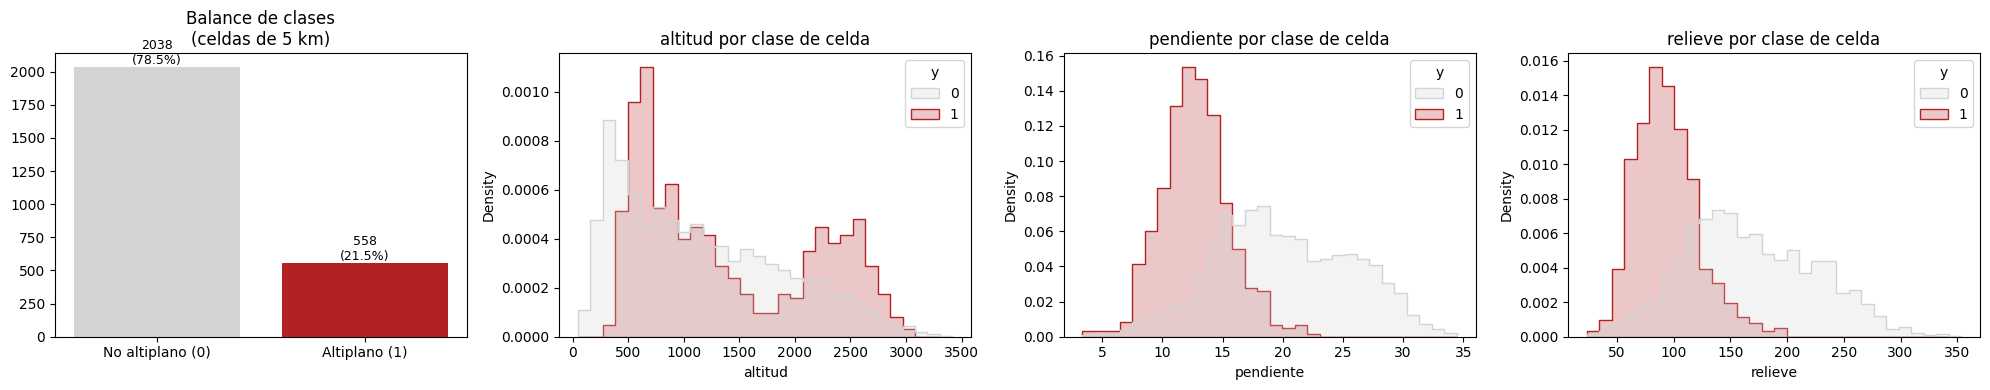

In [5]:
# Exploración gráfica: balance de clases + histograma de cada covariable por clase de celda.
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
colores_clase = {0: "lightgray", 1: "firebrick"}
conteo = df["y"].value_counts().sort_index()
barras = axes[0].bar(["No altiplano (0)", "Altiplano (1)"], [conteo.get(0, 0), conteo.get(1, 0)],
                     color=[colores_clase[0], colores_clase[1]])
for b, v in zip(barras, [conteo.get(0, 0), conteo.get(1, 0)]):
    axes[0].text(b.get_x()+b.get_width()/2, b.get_height(), f"{v}\n({100*v/N:.1f}%)",
                 ha="center", va="bottom", fontsize=9)
axes[0].set_title("Balance de clases\n(celdas de 5 km)")
for ax, var, col in zip(axes[1:], ["altitud", "pendiente", "relieve"],
                        ["steelblue", "darkorange", "seagreen"]):
    sns.histplot(data=df, x=var, hue="y", bins=30, palette=colores_clase, ax=ax,
                 element="step", stat="density", common_norm=False)   # densidad por clase (comparables)
    ax.set_title(f"{var} por clase de celda")
plt.tight_layout()
plt.savefig(os.path.join(CARPETA_FIGURAS, "00_exploracion_celdas.png"), dpi=150)
plt.show()


## [4] Construir la matriz de vecindad Rook (contigüidad real)

Cada celda de 5 km se conecta con sus vecinas Norte/Sur/Este/Oeste **si también son válidas**
— contigüidad Rook verdadera sobre la grilla regular, el insumo que exige el CAR. Se reporta
explícitamente cuántas celdas quedan sin vecinos (islas): a diferencia de `DistanceBand`
sobre los 491 centroides (`02_v2`), una grilla contigua no debería dejar islas.


In [6]:
# Construye la lista de aristas de vecindad Rook (arriba/abajo/izq/der) = base de la matriz W del CAR.
idx_map = -np.ones((nrow, ncol), dtype=int)
idx_map[filas, cols] = np.arange(N)   # mapea (fila,col) de grilla -> índice 0..N-1 de la celda válida

aristas = []
for cid, (i, j) in enumerate(zip(filas, cols)):
    for di, dj in [(0, 1), (1, 0), (0, -1), (-1, 0)]:   # 4 vecinos ortogonales (contiguidad Rook)
        ni, nj = i + di, j + dj
        if 0 <= ni < nrow and 0 <= nj < ncol and mask_celda[ni, nj]:
            vecino = idx_map[ni, nj]
            if vecino > cid:   # sólo una vez por par (evita duplicar la arista)
                aristas.append((cid + 1, vecino + 1))   # 1-based porque R indexa desde 1
aristas = np.array(aristas, dtype=int)

grados = np.zeros(N, dtype=int)
for a, b in aristas:
    grados[a - 1] += 1; grados[b - 1] += 1   # grado = nº de vecinos de cada celda
islas = int((grados == 0).sum())             # celdas sin vecinos (problemáticas para el CAR)
print(f"Aristas Rook: {len(aristas)}  |  grado medio: {2*len(aristas)/N:.2f}  |  celdas sin vecinos (islas): {islas}")

Aristas Rook: 5007  |  grado medio: 3.86  |  celdas sin vecinos (islas): 0


## [5] Exportar la tabla y la adyacencia para R

In [7]:
# geometria de cada celda (poligono de 5 km) para mapear despues
geoms, xs, ys = [], [], []
for i, j in zip(filas, cols):
    # Esquinas superior-izquierda e inferior-derecha del bloque -> caja (box) de 5 km.
    x0, y0 = rasterio.transform.xy(ref_transform, i * F, j * F, offset="ul")
    x1, y1 = rasterio.transform.xy(ref_transform, (i + 1) * F, (j + 1) * F, offset="ul")
    geoms.append(box(min(x0, x1), min(y0, y1), max(x0, x1), max(y0, y1)))
    xs.append((x0 + x1) / 2); ys.append((y0 + y1) / 2)   # centroide de la celda

# Exporta a CSV lo que R necesita: covariables+etiqueta (celdas.csv) y la vecindad (edges.csv).
df_export = df[["y", "altitud", "pendiente", "relieve", "region"]].copy()
df_export.to_csv(os.path.join(CARPETA_IO, "celdas.csv"), index=False)
np.savetxt(os.path.join(CARPETA_IO, "edges.csv"), aristas, fmt="%d", delimiter=",",
           header="a,b", comments="")
print(f"Exportado celdas.csv ({len(df_export)} filas) y edges.csv ({len(aristas)} aristas) a:\n  {CARPETA_IO}")

Exportado celdas.csv (2596 filas) y edges.csv (5007 aristas) a:
  C:\Users\MSI\Desktop\Universidad\Analisis_Geoespacial\Resultados\11_CAR_io



## [6] Escribir el script de R (CARBayes) — se ejecuta en la celda siguiente

Se ajustan **tres modelos** sobre la misma tabla/adyacencia para poder aislar qué aporta
cada componente:

- **M0 — GLM binomial NO espacial** (`S.glm`, covariables + región): línea base sin efecto
  espacial.
- **M1 — CAR Leroux SIN región** (`S.CARleroux`, solo covariables + efecto espacial): mide
  cuánto aporta el suavizado espacial por sí solo.
- **M2 — CAR Leroux + región** (covariables + región + efecto espacial): el modelo
  principal, que combina zonas (los clusters) y heterogeneidad espacial fina.

El script escribe de vuelta las probabilidades ajustadas por celda, el efecto aleatorio
espacial φ (media posterior) y una tabla de métricas (DIC, WAIC, p.d, log-verosimilitud,
ρ y τ² con sus intervalos de credibilidad).


In [8]:
# SCRIPT_R = codigo R (string crudo) que se escribe a un .R y se ejecuta con Rscript.
# Ajusta 3 modelos binomiales sobre las celdas: M0 = GLM no espacial (S.glm),
# M1 = CAR Leroux sin region y M2 = CAR Leroux + region (S.CARleroux). Reconstruye la
# matriz de vecindad W desde edges.csv, estandariza covariables y exporta metricas
# (DIC/WAIC), probabilidades ajustadas y coeficientes. Sus propios comentarios en R
# explican el prior IG(2,1) usado para regularizar el efecto espacial.
SCRIPT_R = r'''
.libPaths(Sys.getenv("R_LIBS_USER"))
suppressMessages({library(CARBayes); library(Matrix)})
args <- commandArgs(trailingOnly=TRUE)
IO <- args[1]; BURN <- as.integer(args[2]); NSAMP <- as.integer(args[3]); THR <- as.numeric(args[4])
set.seed(42)

d <- read.csv(file.path(IO,"celdas.csv"))
e <- read.csv(file.path(IO,"edges.csv"))
N <- nrow(d)
W <- matrix(0, N, N)
for (k in 1:nrow(e)) { W[e$a[k], e$b[k]] <- 1; W[e$b[k], e$a[k]] <- 1 }

for (v in c("altitud","pendiente","relieve")) d[[v]] <- as.numeric(scale(d[[v]]))
d$region <- relevel(factor(d$region), ref="1")   # referencia = Farallones (menor tasa)
d$ybin <- d$y
tr1 <- rep(1L, N)

ajustar <- function(formula, espacial) {
  if (espacial) {
    # prior.tau2 = IG(2,1) (media a priori tau2=1): prior debilmente informativo
    # sobre la varianza del efecto espacial. Con el prior vago por defecto IG(1,0.01),
    # el efecto aleatorio por celda produce SEPARACION en el outcome binario (tau2 -> 1e5,
    # DIC=Inf, probabilidades NaN). Es practica estandar regularizarlo asi.
    S.CARleroux(formula, family="binomial", data=d, trials=tr1, W=W,
                prior.tau2=c(2, 1), burnin=BURN, n.sample=NSAMP, thin=1, verbose=FALSE)
  } else {
    S.glm(formula, family="binomial", data=d, trials=tr1,
          burnin=BURN, n.sample=NSAMP, thin=1, verbose=FALSE)
  }
}

t0 <- Sys.time()
m0 <- ajustar(ybin ~ altitud+pendiente+relieve+region, FALSE)
m1 <- ajustar(ybin ~ altitud+pendiente+relieve,        TRUE)
m2 <- ajustar(ybin ~ altitud+pendiente+relieve+region, TRUE)
cat(sprintf("Ajuste de los 3 modelos: %.1f s\n", as.numeric(difftime(Sys.time(),t0,units="secs"))))

fila <- function(m, nombre, espacial) {
  mf <- m$modelfit
  rho <- if (espacial) mean(m$samples$rho) else NA
  rho_lo <- if (espacial) quantile(m$samples$rho,0.025) else NA
  rho_hi <- if (espacial) quantile(m$samples$rho,0.975) else NA
  tau <- if (espacial) mean(m$samples$tau2) else NA
  data.frame(modelo=nombre, DIC=as.numeric(mf["DIC"]), WAIC=as.numeric(mf["WAIC"]),
             p_d=as.numeric(mf["p.d"]), loglik=as.numeric(mf["loglikelihood"]),
             rho=rho, rho_lo=rho_lo, rho_hi=rho_hi, tau2=tau)
}
met <- rbind(fila(m0,"M0_GLM_no_espacial",FALSE),
             fila(m1,"M1_CAR_sin_region",TRUE),
             fila(m2,"M2_CAR_con_region",TRUE))
write.csv(met, file.path(IO,"car_metricas.csv"), row.names=FALSE)

# efecto espacial phi (media posterior) del modelo principal M2
phi <- apply(m2$samples$phi, 2, mean)
res <- data.frame(y=d$ybin,
                  prob_m0=m0$fitted.values,
                  prob_m1=m1$fitted.values,
                  prob_m2=m2$fitted.values,
                  phi=phi)
write.csv(res, file.path(IO,"car_resultados.csv"), row.names=FALSE)

# coeficientes del modelo principal
co <- as.data.frame(m2$summary.results)
co$parametro <- rownames(m2$summary.results)
write.csv(co, file.path(IO,"car_coeficientes.csv"), row.names=FALSE)
cat("Exportado car_metricas.csv, car_resultados.csv, car_coeficientes.csv\n")
'''

# Escribe el script R a disco para que Rscript lo ejecute en la siguiente celda.
ruta_r = os.path.join(CARPETA_IO, "car_fit.R")
with open(ruta_r, "w", encoding="utf-8") as f:
    f.write(SCRIPT_R)
print(f"Script de R escrito en: {ruta_r} ({len(SCRIPT_R)} caracteres)")

Script de R escrito en: C:\Users\MSI\Desktop\Universidad\Analisis_Geoespacial\Resultados\11_CAR_io\car_fit.R (2988 caracteres)



## [7] Ejecutar el CAR en R (MCMC bayesiano)

Cadenas: **13.000 muestras con 3.000 de burn-in** (10.000 útiles), con el prior
débilmente informativo sobre τ² descrito arriba. En esta máquina toma ~6-7 minutos para los
tres modelos. Si la celda falla, revisar que `RSCRIPT` apunte a la instalación de R con
`CARBayes` (ver `CONTEXTO_PROYECTO_v2.md`, sección 5).


In [9]:
# Ejecuta el ajuste bayesiano en R. BURNIN se descarta; N_MUESTRAS-BURNIN quedan para inferencia.
BURNIN, N_MUESTRAS = 3000, 13000
entorno = dict(os.environ)
entorno["R_LIBS_USER"] = r"C:\Users\MSI\AppData\Local\R\win-library\4.6"   # ruta donde está instalado CARBayes

t_r = time.time()
# subprocess.run llama a Rscript pasándole el .R + los argumentos (carpeta IO, burnin, muestras, umbral).
proc = subprocess.run(
    [RSCRIPT, os.path.join(CARPETA_IO, "car_fit.R"), CARPETA_IO,
     str(BURNIN), str(N_MUESTRAS), str(UMBRAL_CELDA_ALTIPLANO)],
    capture_output=True, text=True, env=entorno)   # captura stdout/stderr como texto
print(proc.stdout[-1500:])
if proc.returncode != 0:   # returncode != 0 -> R falló; se muestra el stderr y se aborta
    print("STDERR:\n", proc.stderr[-2000:])
    raise RuntimeError("El ajuste en R fallo")
print(f"\nR terminó en {time.time()-t_r:.0f} s")

Ajuste de los 3 modelos: 161.2 s
Exportado car_metricas.csv, car_resultados.csv, car_coeficientes.csv


R terminó en 168 s


## [8] Leer resultados y reportar métricas de ajuste (DIC, WAIC, ρ, τ²)

In [10]:
# Lee de vuelta los CSV que produjo R y los une al DataFrame de celdas.
metricas_car = pd.read_csv(os.path.join(CARPETA_IO, "car_metricas.csv"))
resultados_car = pd.read_csv(os.path.join(CARPETA_IO, "car_resultados.csv"))
coef_car = pd.read_csv(os.path.join(CARPETA_IO, "car_coeficientes.csv"))

df["prob_m0"] = resultados_car["prob_m0"].values   # probabilidad ajustada de cada modelo
df["prob_m1"] = resultados_car["prob_m1"].values
df["prob_m2"] = resultados_car["prob_m2"].values
df["phi"] = resultados_car["phi"].values           # efecto espacial φ por celda (M2)

print("MÉTRICAS DE AJUSTE BAYESIANO (menor DIC/WAIC = mejor; p.d = nº efectivo de parámetros):")
print(metricas_car.round(3).to_string(index=False))
print("\nInterpretación de ρ (fuerza de la dependencia espacial en el CAR):")
# ρ (rho de Leroux) mide cuánta autocorrelación espacial hay; se reporta con su IC95% y τ².
for _, r in metricas_car[metricas_car["rho"].notna()].iterrows():
    print(f"  {r['modelo']}: ρ = {r['rho']:.3f}  IC95% [{r['rho_lo']:.3f}, {r['rho_hi']:.3f}]  "
          f"(τ² = {r['tau2']:.3f})")
# Regla práctica: caída de DIC > 10 = mejora sustancial del modelo espacial sobre el no espacial.
mejora_dic = metricas_car.iloc[0]["DIC"] - metricas_car.iloc[2]["DIC"]
print(f"\nReducción de DIC de M2 (CAR+región) frente a M0 (GLM no espacial): {mejora_dic:.1f} "
      f"({'mejora sustancial' if mejora_dic > 10 else 'mejora marginal'}).")

MÉTRICAS DE AJUSTE BAYESIANO (menor DIC/WAIC = mejor; p.d = nº efectivo de parámetros):
            modelo      DIC     WAIC     p_d   loglik   rho  rho_lo  rho_hi   tau2
M0_GLM_no_espacial 1268.544 1269.025   5.659 -628.613   NaN     NaN     NaN    NaN
 M1_CAR_sin_region  658.116  607.514 303.750  -25.308 0.993    0.98   0.999 77.766
 M2_CAR_con_region  734.600  689.864 317.124  -50.176 0.990    0.97   0.999 50.428

Interpretación de ρ (fuerza de la dependencia espacial en el CAR):
  M1_CAR_sin_region: ρ = 0.993  IC95% [0.980, 0.999]  (τ² = 77.766)
  M2_CAR_con_region: ρ = 0.990  IC95% [0.970, 0.999]  (τ² = 50.428)

Reducción de DIC de M2 (CAR+región) frente a M0 (GLM no espacial): 533.9 (mejora sustancial).


In [11]:
# Coeficientes del modelo principal M2 (mediana posterior e IC95% que exportó R).
print("COEFICIENTES DEL MODELO PRINCIPAL M2 (CAR + región), media posterior e IC95%:")
cols_ver = [c for c in ["parametro", "Median", "2.5%", "97.5%"] if c in coef_car.columns]
print(coef_car[cols_ver].round(4).to_string(index=False))
print("\n(Las dummies de región son 'exceso de log-odds de ser celda-Altiplano' frente a la "
      "región de referencia = Farallones, la de menor tasa. El efecto espacial ρWφ absorbe la "
      "heterogeneidad fina que no capturan ni las covariables ni las regiones.)")

COEFICIENTES DEL MODELO PRINCIPAL M2 (CAR + región), media posterior e IC95%:
  parametro     2.5%    97.5%
(Intercept) -21.5725  -9.7855
    altitud   4.1915  12.4212
  pendiente  -7.8259   4.2991
    relieve -15.4070  -3.5256
    region0   4.9775  11.5606
    region2   6.7573  22.7166
    region3  -0.9767   5.7296
       tau2  10.6644 124.1738
        rho   0.9696   0.9989

(Las dummies de región son 'exceso de log-odds de ser celda-Altiplano' frente a la región de referencia = Farallones, la de menor tasa. El efecto espacial ρWφ absorbe la heterogeneidad fina que no capturan ni las covariables ni las regiones.)



## [9] Métricas de clasificación por celda (secundarias — leer con la nota de abajo)

**Advertencia interpretativa (importante):** estas métricas son **dentro de muestra** y para
el CAR el AUC saldrá ≈ 1 — no porque "prediga perfecto", sino porque el efecto aleatorio
espacial tiene ~un parámetro por celda y **reproduce el mapa observado**. Por eso la
comparación de modelos **debe hacerse con DIC/WAIC de la sección [8]** (que penalizan ese
exceso de parámetros vía p.d), no con el AUC. El GLM no espacial (M0), al no tener efecto
aleatorio, sí da un AUC in-sample honesto (≈ 0,94) — es la referencia de discriminación por
covariables + región.


In [12]:
def metricas_clasificacion(y_real, y_prob, nombre, umbral=0.5):
    # Métricas de clasificación (enfocadas en Altiplano=1) a partir de la probabilidad ajustada.
    # NOTA: aquí son EN-MUESTRA (el CAR no da predicción out-of-sample); comparar vía DIC/WAIC.
    y_pred = (y_prob >= umbral).astype(int)
    rep = classification_report(y_real, y_pred, target_names=["No altiplano", "Altiplano"],
                                output_dict=True, zero_division=0)
    auc = roc_auc_score(y_real, y_prob)
    return {"Modelo": nombre, "AUC": auc, "Recall_Altiplano": rep["Altiplano"]["recall"],
            "Precision_Altiplano": rep["Altiplano"]["precision"], "F1_Altiplano": rep["Altiplano"]["f1-score"],
            "Accuracy": rep["accuracy"]}

tabla_clf = pd.DataFrame([
    metricas_clasificacion(df["y"], df["prob_m0"], "M0 · GLM no espacial (+región)"),
    metricas_clasificacion(df["y"], df["prob_m1"], "M1 · CAR Leroux (sin región)"),
    metricas_clasificacion(df["y"], df["prob_m2"], "M2 · CAR Leroux (+región)"),
])
print(tabla_clf.round(4).to_string(index=False))

                        Modelo    AUC  Recall_Altiplano  Precision_Altiplano  F1_Altiplano  Accuracy
M0 · GLM no espacial (+región) 0.9427            0.7061               0.7912        0.7462    0.8968
  M1 · CAR Leroux (sin región) 1.0000            0.9982               1.0000        0.9991    0.9996
     M2 · CAR Leroux (+región) 0.9999            0.9839               0.9964        0.9901    0.9958


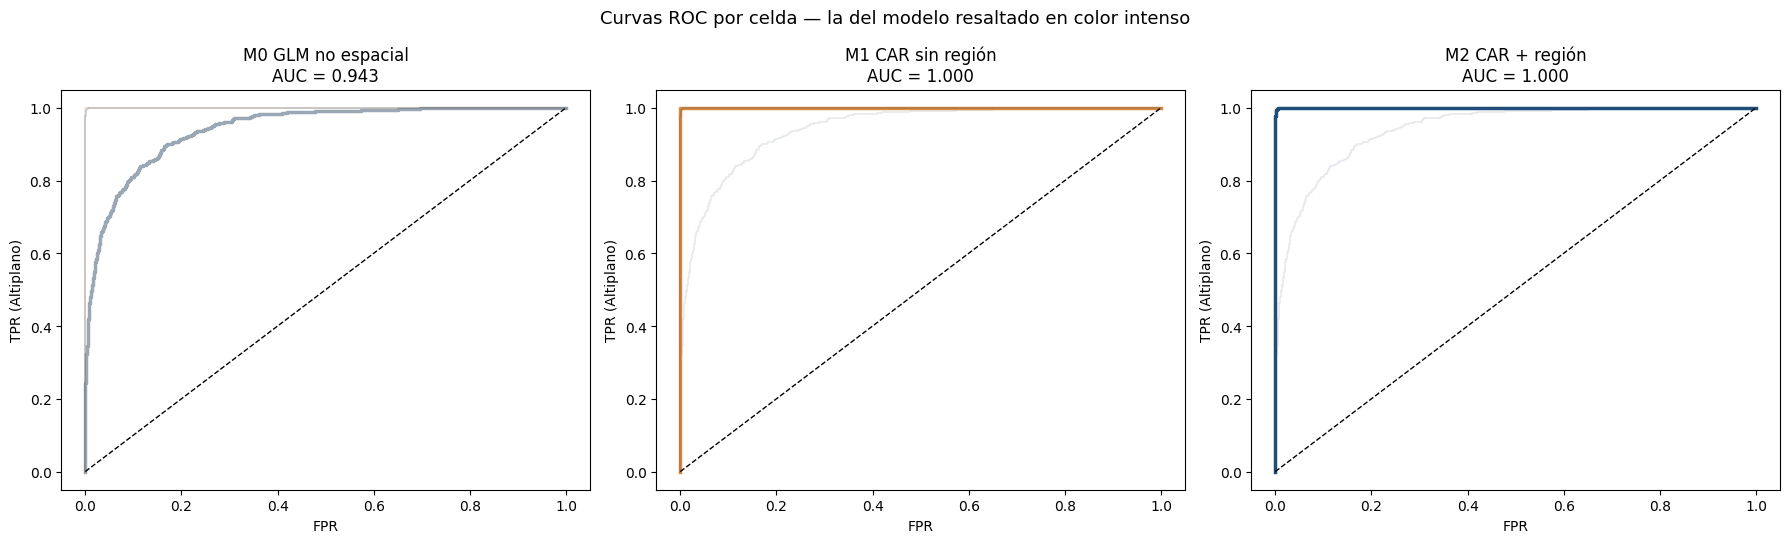

In [13]:
# Figura: matrices de confusión + ROC de los 3 modelos
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
for ax, col, nombre in zip(axes, ["prob_m0", "prob_m1", "prob_m2"],
                           ["M0 GLM no espacial", "M1 CAR sin región", "M2 CAR + región"]):
    # En cada panel se dibujan las 3 curvas; la del modelo del panel se resalta en color intenso.
    for c2, cc in zip(["prob_m0", "prob_m1", "prob_m2"], ["#9aa7b4", "#e08a3c", "#1f4e79"]):
        fpr, tpr, _ = roc_curve(df["y"], df[c2])
        ax.plot(fpr, tpr, color=cc, alpha=0.25 if c2 != col else 1.0,
                lw=2.5 if c2 == col else 1.2)
    fpr, tpr, _ = roc_curve(df["y"], df[col])
    auc = roc_auc_score(df["y"], df[col])
    ax.plot([0, 1], [0, 1], "k--", lw=1)   # diagonal = azar
    ax.set_title(f"{nombre}\nAUC = {auc:.3f}")
    ax.set_xlabel("FPR"); ax.set_ylabel("TPR (Altiplano)")
plt.suptitle("Curvas ROC por celda — la del modelo resaltado en color intenso", fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(CARPETA_FIGURAS, "01_roc_comparacion.png"), dpi=150)
plt.show()


## [10] Mapas: probabilidad ajustada y el efecto espacial φ (la heterogeneidad capturada)

Se construyen las celdas de 5 km como polígonos y se mapean con la plantilla cartográfica
del proyecto. El **efecto aleatorio espacial φ** es, literalmente, la heterogeneidad
espacial que el CAR incorpora: valores altos donde hay más celdas-Altiplano de lo que
explican las covariables y la región, y viceversa.


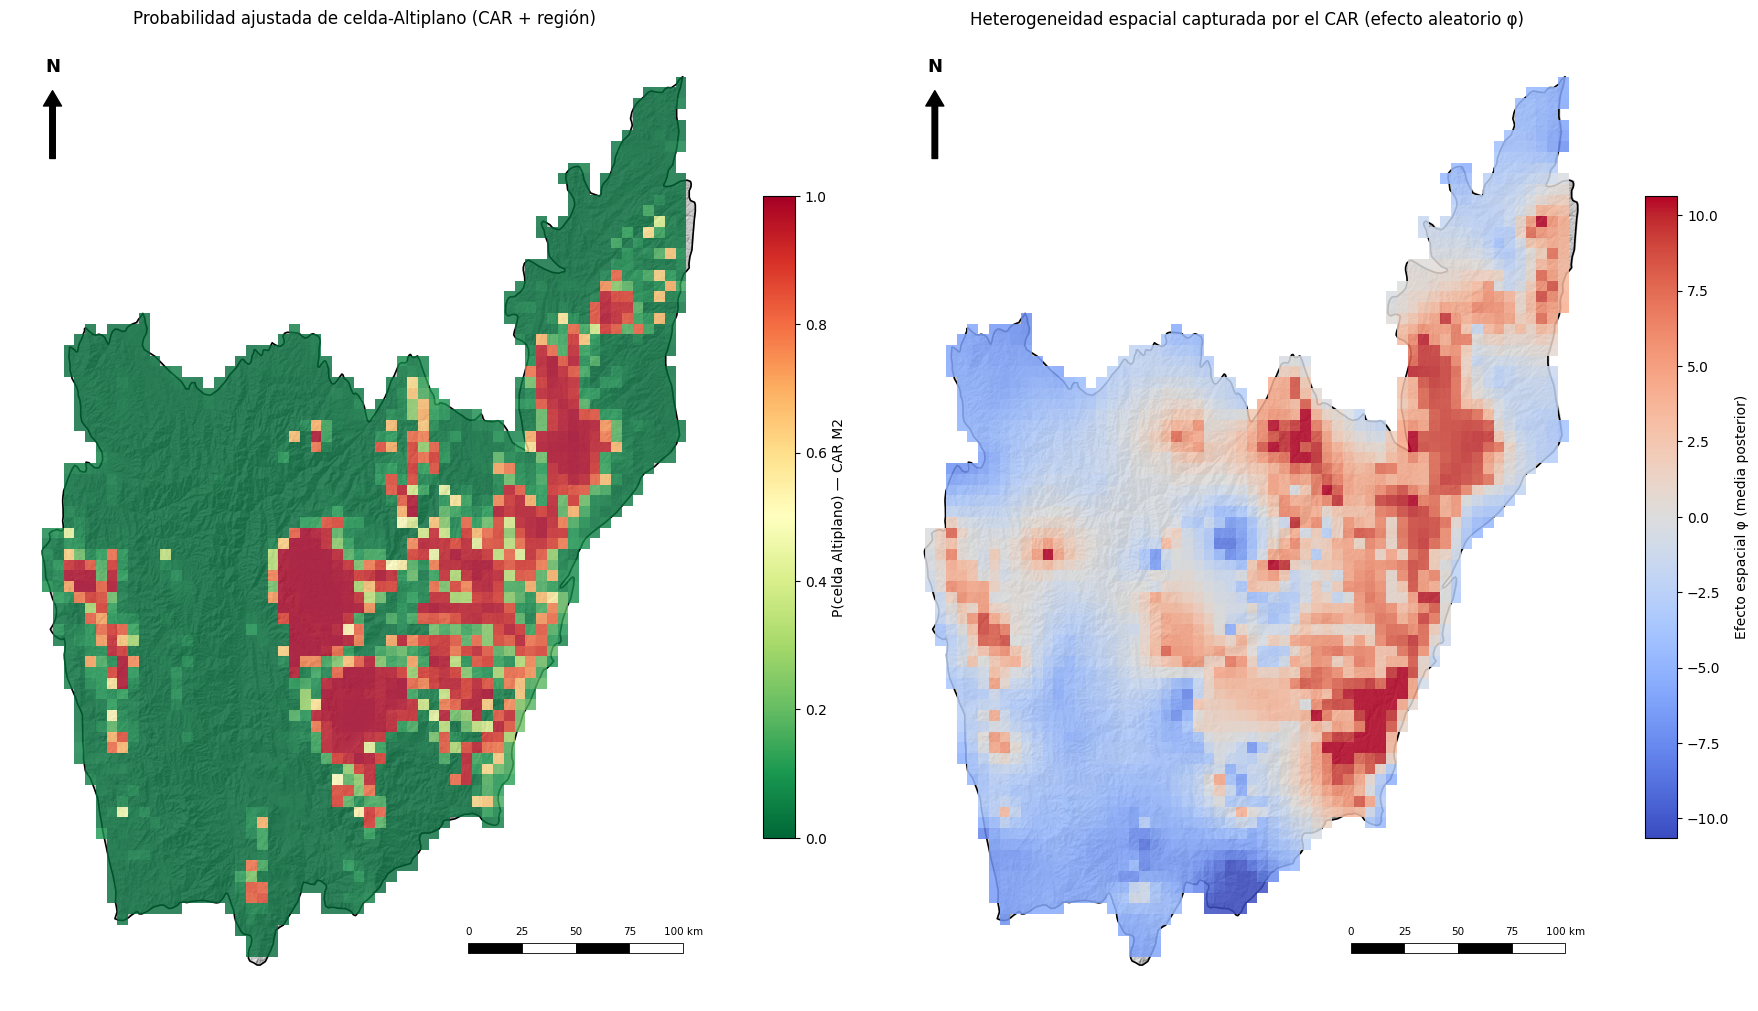

In [14]:
# Mapas cartográficos (plantilla): probabilidad ajustada M2 y el efecto espacial φ del CAR.
import sys
sys.path.insert(0, os.path.join(RAIZ, "Codigo"))
from plantilla_mapas import aplicar_plantilla_mapa, CARPETA_IMAGENES

gdf = gpd.GeoDataFrame(df.copy(), geometry=geoms, crs=ref_crs)   # celdas como polígonos para mapear
CARPETA_IMAGENES_NB = os.path.join(CARPETA_IMAGENES, "11_CAR_altiplanos_v2")
os.makedirs(CARPETA_IMAGENES_NB, exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(18, 11))
aplicar_plantilla_mapa(axes[0], extent_de=gdf)
gdf.plot(column="prob_m2", cmap="RdYlGn_r", vmin=0, vmax=1, alpha=0.8, zorder=5, ax=axes[0],
         legend=True, legend_kwds={"label": "P(celda Altiplano) — CAR M2", "shrink": 0.6})
axes[0].set_title("Probabilidad ajustada de celda-Altiplano (CAR + región)")
axes[0].set_axis_off()

aplicar_plantilla_mapa(axes[1], extent_de=gdf)
lim = np.abs(gdf["phi"]).quantile(0.98)   # límite simétrico robusto (percentil 98) para centrar φ en 0
gdf.plot(column="phi", cmap="coolwarm", vmin=-lim, vmax=lim, alpha=0.85, zorder=5, ax=axes[1],
         legend=True, legend_kwds={"label": "Efecto espacial φ (media posterior)", "shrink": 0.6})
axes[1].set_title("Heterogeneidad espacial capturada por el CAR (efecto aleatorio φ)")
axes[1].set_axis_off()
plt.tight_layout()
plt.savefig(os.path.join(CARPETA_IMAGENES_NB, "02_mapa_prob_y_phi.png"), dpi=150)
plt.show()

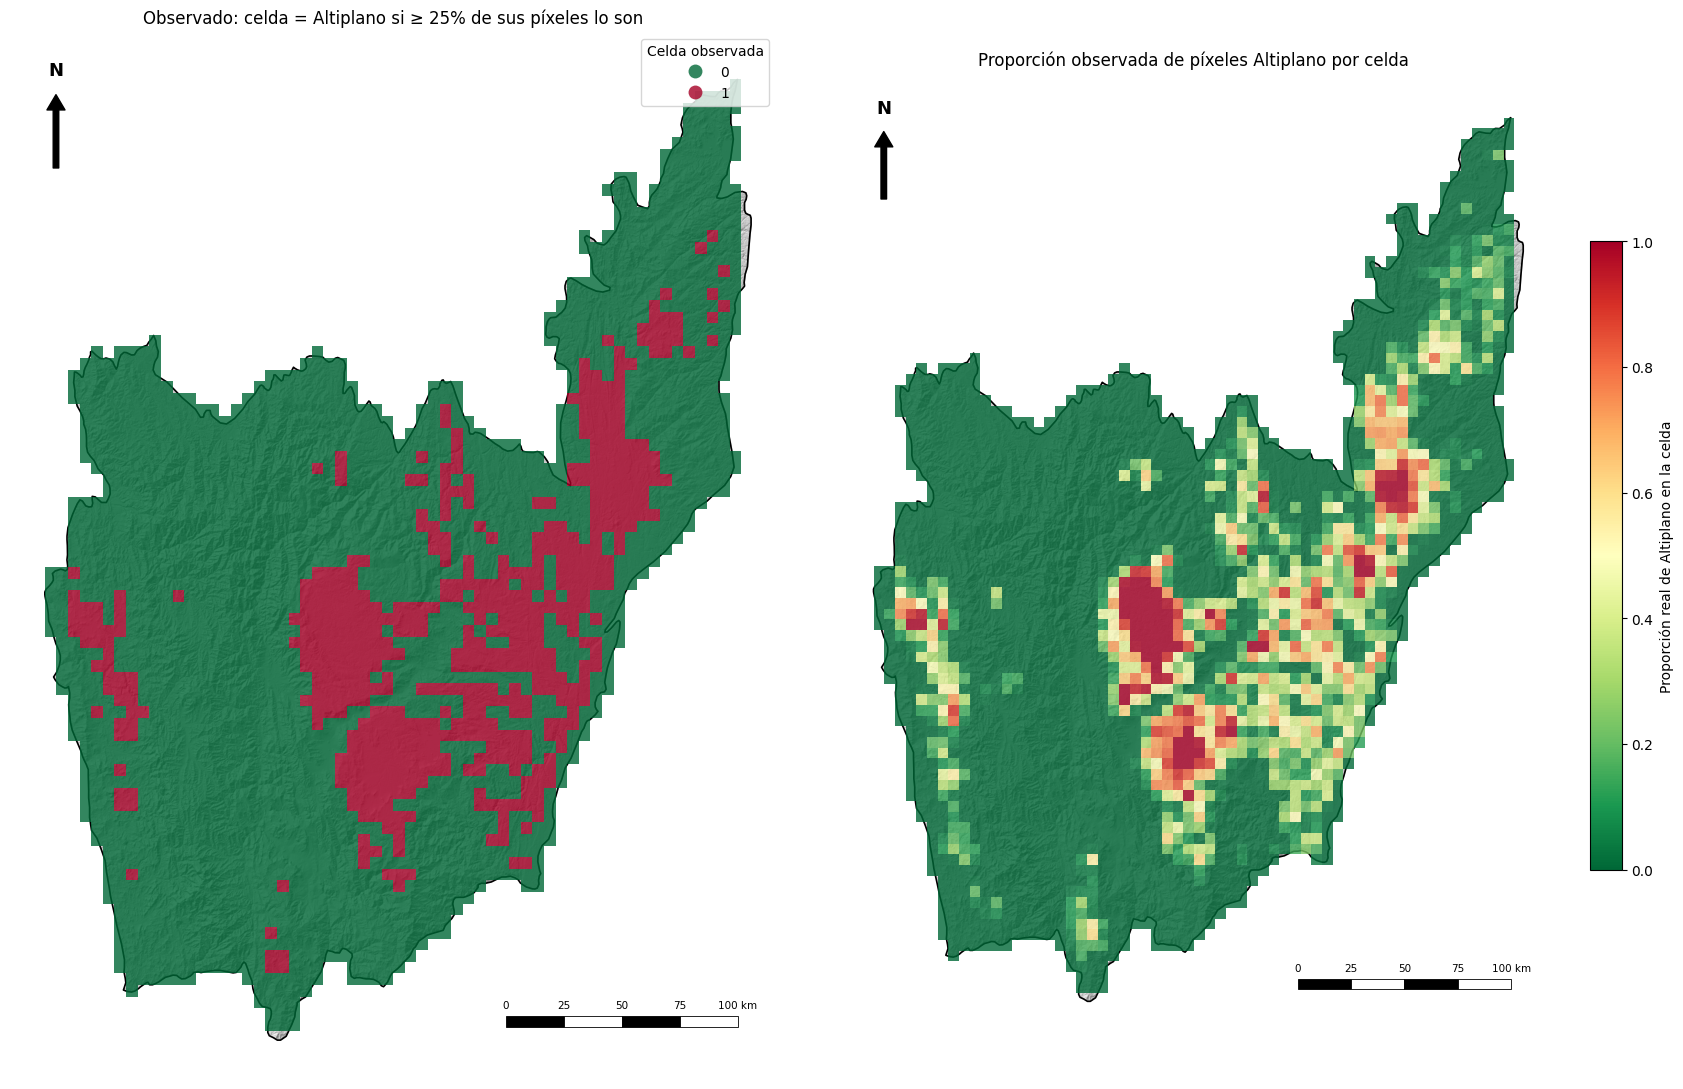

In [15]:
# Mapa: celdas observadas (Altiplano/No) vs probabilidad — control visual del ajuste
fig, axes = plt.subplots(1, 2, figsize=(18, 11))
aplicar_plantilla_mapa(axes[0], extent_de=gdf)
gdf.plot(column="y", categorical=True, cmap="RdYlGn_r", alpha=0.8, zorder=5, ax=axes[0],
         legend=True, legend_kwds={"title": "Celda observada"})   # etiqueta binaria observada
axes[0].set_title(f"Observado: celda = Altiplano si ≥ {UMBRAL_CELDA_ALTIPLANO:.0%} de sus píxeles lo son")
axes[0].set_axis_off()

aplicar_plantilla_mapa(axes[1], extent_de=gdf)
gdf.plot(column="prop_alt", cmap="RdYlGn_r", vmin=0, vmax=1, alpha=0.8, zorder=5, ax=axes[1],
         legend=True, legend_kwds={"label": "Proporción real de Altiplano en la celda", "shrink": 0.6})   # proporción continua
axes[1].set_title("Proporción observada de píxeles Altiplano por celda")
axes[1].set_axis_off()
plt.tight_layout()
plt.savefig(os.path.join(CARPETA_IMAGENES_NB, "03_mapa_observado.png"), dpi=150)
plt.show()

## [11] Exportar resultados

In [16]:
# Exporta la capa de celdas (GeoPackage) + las tablas de métricas a la carpeta de figuras.
ruta_salida = os.path.join(CARPETA_RESULTADOS, "celdas_car_v2.gpkg")
gdf.drop(columns=["region_nombre"]).to_file(ruta_salida, driver="GPKG")   # se descarta la col. de texto
metricas_car.to_csv(os.path.join(CARPETA_FIGURAS, "metricas_ajuste_car.csv"), index=False)
tabla_clf.to_csv(os.path.join(CARPETA_FIGURAS, "metricas_clasificacion_car.csv"), index=False)
print(f"Capa de celdas guardada en: {ruta_salida}")
print(f"TIEMPO TOTAL DEL NOTEBOOK: {time.time()-t_inicio:.0f} s")

Capa de celdas guardada en: C:\Users\MSI\Desktop\Universidad\Analisis_Geoespacial\Resultados\celdas_car_v2.gpkg
TIEMPO TOTAL DEL NOTEBOOK: 246 s



## Conclusiones

- **El efecto espacial CAR sí incorpora heterogeneidad real:** el parámetro de dependencia
  espacial ρ del CAR de Leroux es **≈ 0,99** con intervalo de credibilidad lejos de 0
  (M1: ρ=0,993, IC[0,98–0,999]; M2: ρ=0,990) — estructura espacial fortísima, cercana a un
  CAR intrínseco. El mapa de φ (sección [10]) *es* esa heterogeneidad: rojo donde hay más
  celdas-Altiplano de lo que explican covariables y región (valles centro-orientales y la
  cordillera nororiental), azul donde hay menos (occidente y sur).

- **Mejora sustancial sobre el modelo no espacial:** el CAR baja el DIC de **1268,5 (GLM) a
  658,1 (M1)** y el WAIC de 1269 a 608 — mejora enorme, a costa de subir el p.d (nº efectivo
  de parámetros) de 5,7 a ~304, el "precio" del efecto aleatorio espacial. Como el DIC/WAIC
  ya penalizan ese precio, la mejora es neta. **El AUC in-sample del CAR (≈ 1) NO es
  capacidad predictiva:** el efecto aleatorio reproduce el mapa observado; la comparación
  honesta es por DIC/WAIC.

- **Hallazgo sobre los clusters (contraintuitivo pero limpio):** agregar la zonificación de
  `Clustering_Regiones_v2` como efecto fijo *encima* del CAR **no mejora — lo empeora
  ligeramente** (DIC M1=658 → M2=735; WAIC 608 → 690). La razón es interpretable: las 4
  regiones son bloques contiguos de celdas y **el campo espacial suave del CAR ya reproduce
  esa variación regional (y más fina)**, así que las dummies de región se vuelven redundantes
  y solo suman complejidad. Es decir, el CAR *subsume* a los clusters. (En el GLM no espacial
  las regiones sí son muy informativas — ver sus coeficientes en [8]; es solo frente al
  efecto espacial que pierden aporte.)

- **Relación con el resto del proyecto:** el CAR es la tercera respuesta a la
  autocorrelación diagnosticada en `04_v2` (Moran's I de residuos = 0,610), complementaria a
  la jerárquica (`05_v2`) y a la SAR (`10_SAR`). A diferencia de SAR/GWR (que modelan la
  altitud de altiplanos ya conocidos), el CAR modela directamente la **presencia de altiplano
  por zona** e incorpora la heterogeneidad como un campo espacial suave. Y a diferencia del
  modelo jerárquico —donde las Regiones sí ganaban a las Cordilleras—, aquí el suavizado
  espacial es tan fuerte que hace redundante *cualquier* zonificación discreta.

- **Limitaciones honestas:** (1) resolución de 5 km por la restricción computacional de la
  matriz densa de `CARBayes` — un CAR a 1 km necesitaría `INLA` (no disponible en Windows) o
  matrices dispersas; (2) evaluación dentro de muestra (el CAR es un suavizador de todo el
  mapa, no un predictor train/test), mitigada reportando DIC/WAIC que penalizan la
  complejidad; (3) el binomial de conteo divergió por saturación de denominadores grandes, y
  el binario requirió un prior débilmente informativo sobre τ² (IG(2,1)) para evitar
  separación — ambos documentados como hallazgos metodológicos.
